# Testing if the October 2025 had record breaking rain on some stations

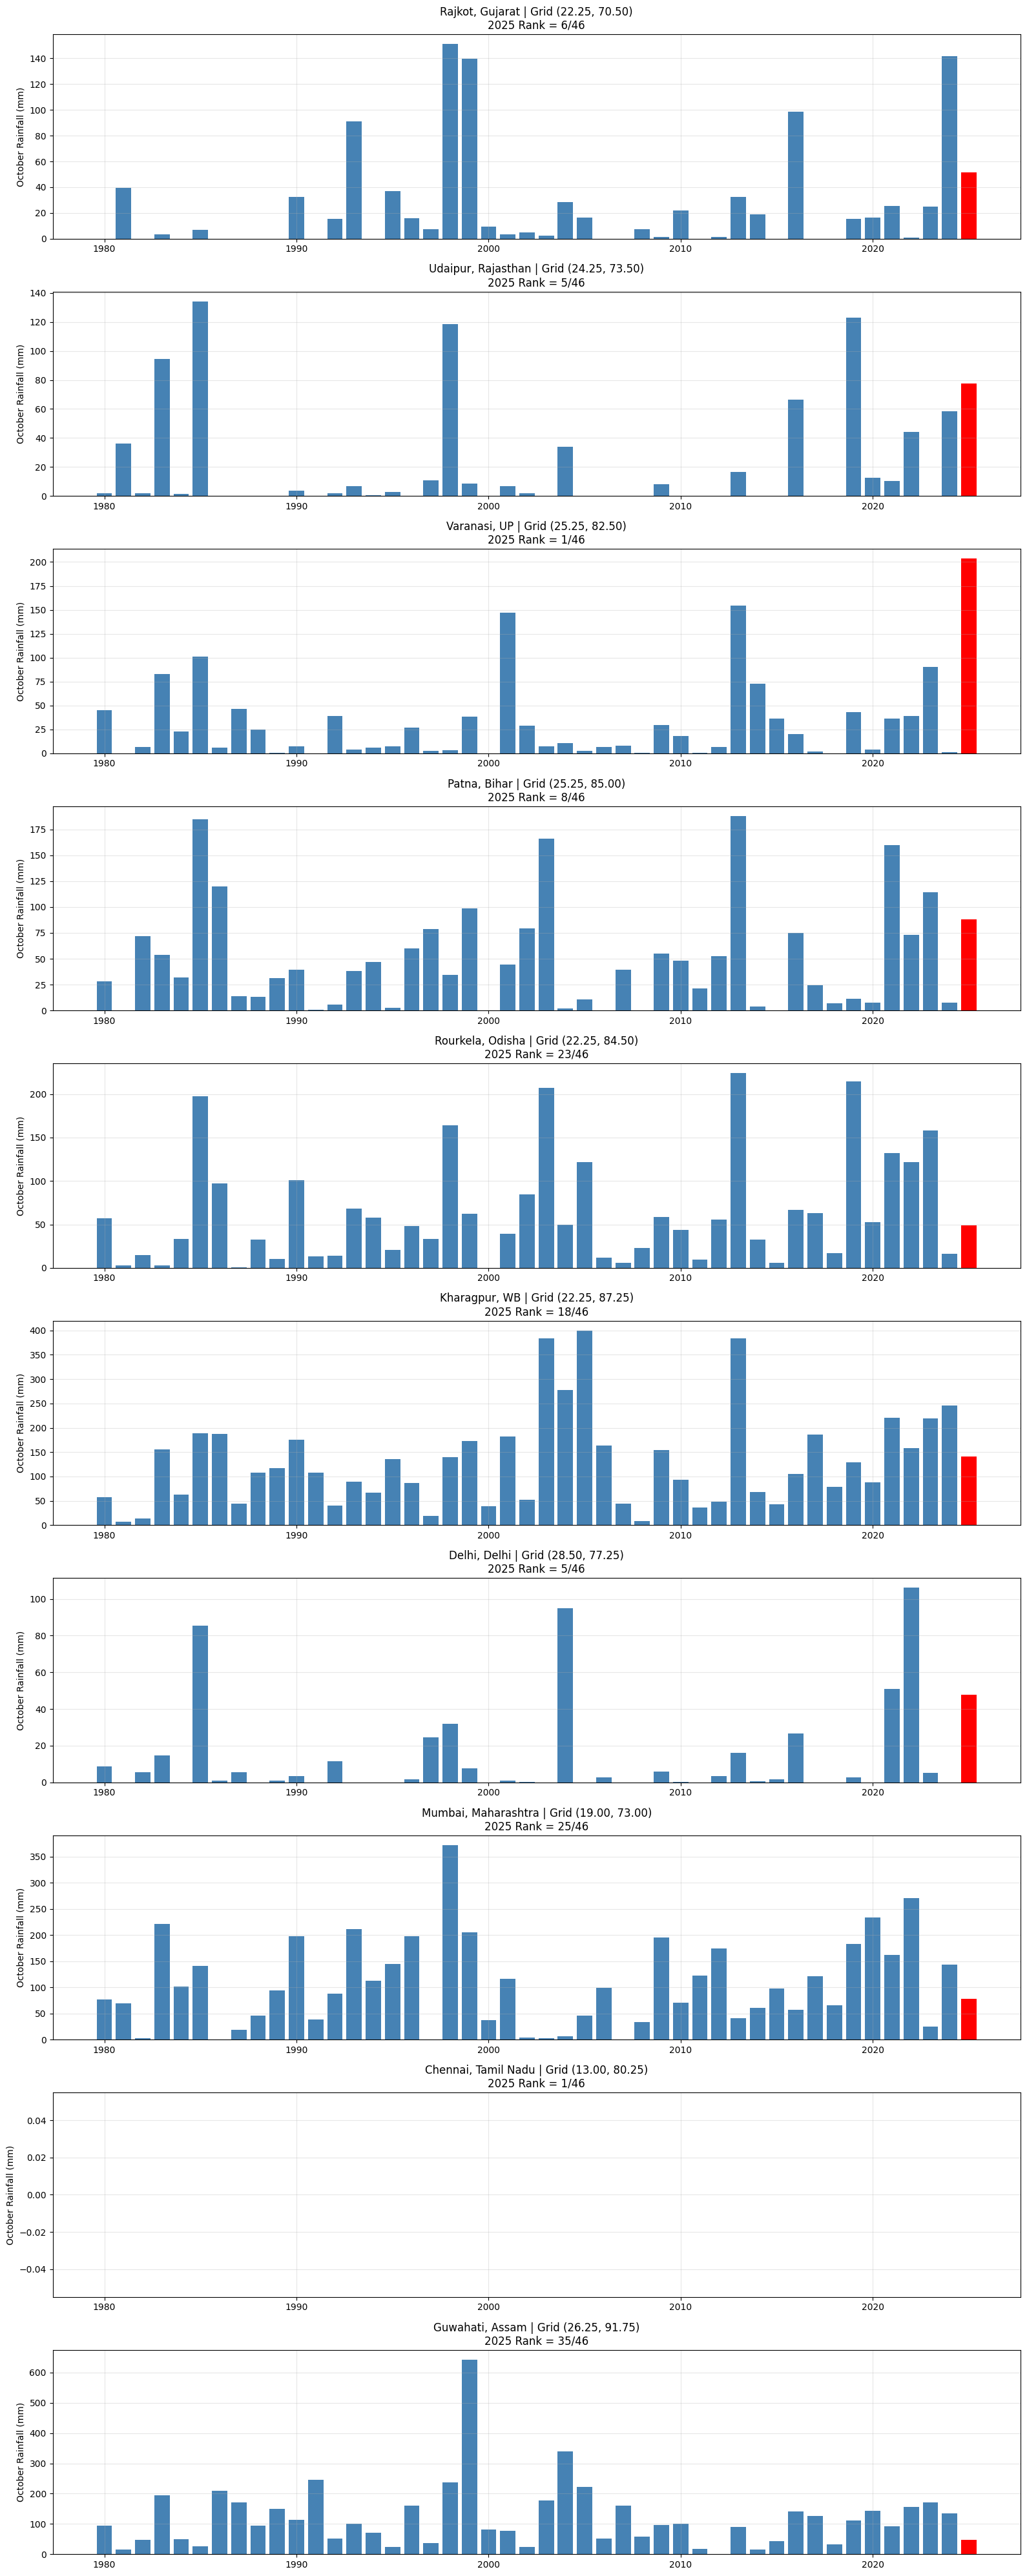



              Location  Grid Lat  Grid Lon  2025 Rank  October 2025 Rainfall  \
0      Rajkot, Gujarat     22.25     70.50          6              51.261269   
1   Udaipur, Rajasthan     24.25     73.50          5              77.670776   
2         Varanasi, UP     25.25     82.50          1             203.556335   
3         Patna, Bihar     25.25     85.00          8              87.889778   
4     Rourkela, Odisha     22.25     84.50         23              48.984722   
5        Kharagpur, WB     22.25     87.25         18             141.622345   
6         Delhi, Delhi     28.50     77.25          5              47.850281   
7  Mumbai, Maharashtra     19.00     73.00         25              78.505569   
8  Chennai, Tamil Nadu     13.00     80.25          1               0.000000   
9      Guwahati, Assam     26.25     91.75         35              48.285645   

   Wettest October Year  Wettest October Rainfall  
0                  1998                151.103058  
1            

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# USER INPUT
# =====================================================

merged_file = r"D:\PHD IIT KGP\2. IMD GRIED (0.25X0.25) RAINFALL\IMD_Rainfall_Merged.nc"

locations = [
    ("Rajkot, Gujarat",   22.18, 70.48),
    ("Udaipur, Rajasthan",  24.34, 73.42),
    ("Varanasi, UP", 25.18, 82.57),
    ("Patna, Bihar",   25.34, 85.08),
    ("Rourkela, Odisha", 22.15, 84.51),
    ("Kharagpur, WB", 22.35, 87.32),
    ("Delhi, Delhi",     28.61, 77.21),
    ("Mumbai, Maharashtra",    19.07, 72.88),
    ("Chennai, Tamil Nadu",   13.08, 80.27),
    ("Guwahati, Assam",  26.14, 91.74),
]

# =====================================================
# READ DATA
# =====================================================

ds = xr.open_dataset(merged_file)

rain_var = list(ds.data_vars)[0]

# =====================================================
# OCTOBER ONLY
# =====================================================

oct_ds = ds.sel(
    TIME=ds.TIME.dt.month == 10
)

# =====================================================
# PLOT
# =====================================================

nloc = len(locations)

fig, axes = plt.subplots(
    nloc,
    1,
    figsize=(16, 4*nloc),
    sharex=False
)

if nloc == 1:
    axes = [axes]

summary = []

# =====================================================
# LOOP THROUGH LOCATIONS
# =====================================================

for ax, (name, lat, lon) in zip(axes, locations):

    # nearest grid
    rain = oct_ds[rain_var].sel(
        LATITUDE=lat,
        LONGITUDE=lon,
        method="nearest"
    )

    actual_lat = float(rain.LATITUDE.values)
    actual_lon = float(rain.LONGITUDE.values)

    # yearly October totals
    oct_total = (
        rain
        .groupby("TIME.year")
        .sum("TIME")
    )

    years = oct_total.year.values
    totals = oct_total.values

    # ranking
    order = np.argsort(totals)[::-1]

    rank_years = years[order]
    rank_totals = totals[order]

    # 2025 rank
    rank_2025 = np.where(rank_years == 2025)[0][0] + 1

    total_2025 = float(
        oct_total.sel(year=2025).values
    )

    record_total = float(rank_totals[0])
    record_year = int(rank_years[0])

    summary.append([
        name,
        actual_lat,
        actual_lon,
        rank_2025,
        total_2025,
        record_year,
        record_total
    ])

    # -------------------------------------------------
    # BAR PLOT
    # -------------------------------------------------

    colors = [
        "red" if y == 2025 else "steelblue"
        for y in years
    ]

    ax.bar(
        years,
        totals,
        color=colors
    )

    ax.set_title(
        f"{name} | Grid ({actual_lat:.2f}, {actual_lon:.2f})"
        f"\n2025 Rank = {rank_2025}/{len(years)}"
    )

    ax.set_ylabel("October Rainfall (mm)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================
# SUMMARY TABLE
# =====================================================

summary_df = pd.DataFrame(
    summary,
    columns=[
        "Location",
        "Grid Lat",
        "Grid Lon",
        "2025 Rank",
        "October 2025 Rainfall",
        "Wettest October Year",
        "Wettest October Rainfall"
    ]
)

print("\n")
print(summary_df)

summary_df.to_excel(
    "October2025_Ranking.xlsx",
    index=False
)

print("\nSaved: October2025_Ranking.xlsx")

# Ranking the 2025 rainfall for each day

C:\Users\Nimta\AppData\Local\Temp\ipykernel_33164\730596659.py:126: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  idx = hist["rain"].idxmax()


KeyError: nan

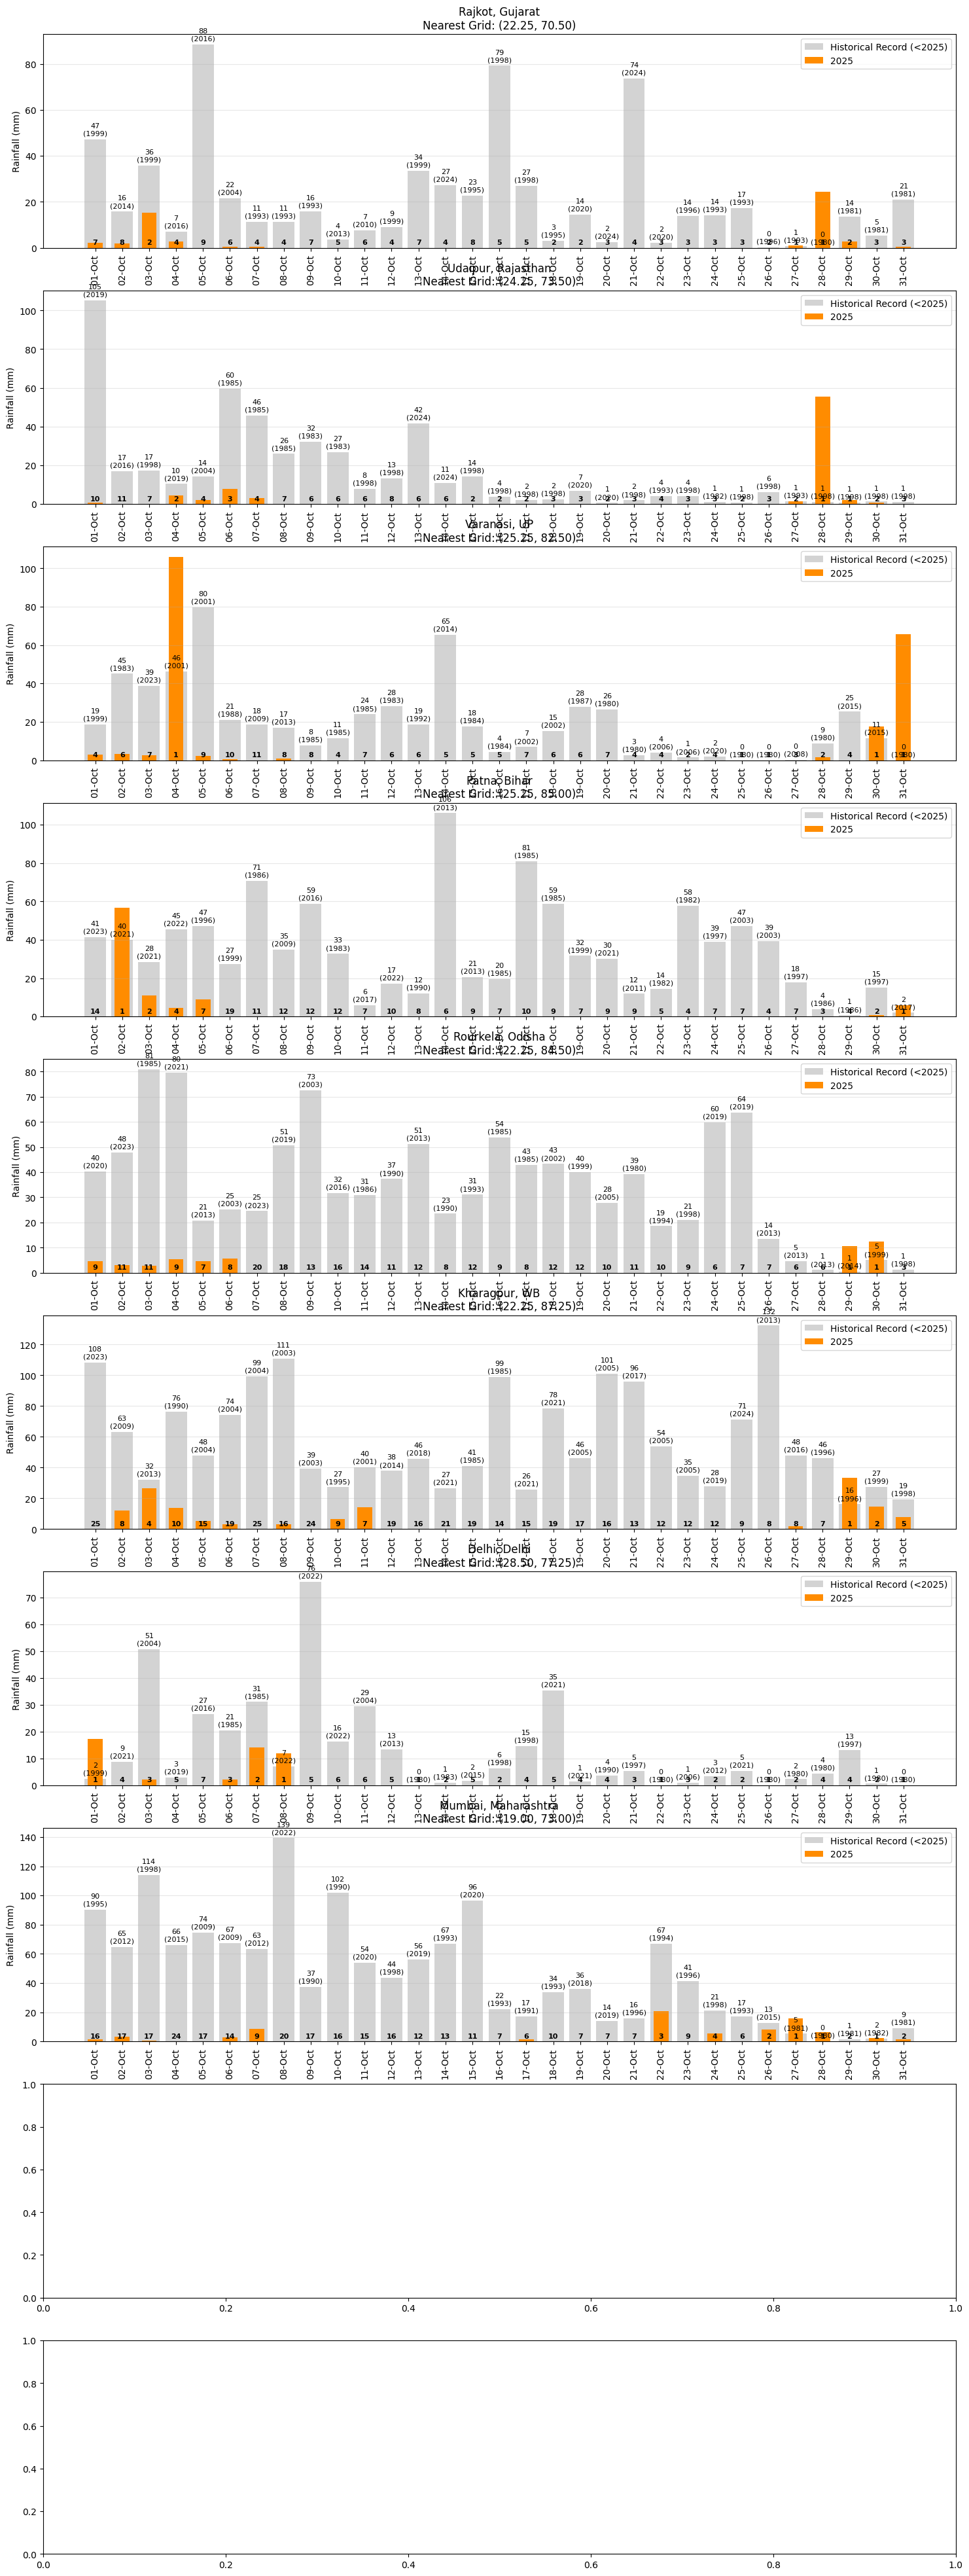

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# USER INPUT
# =====================================================

merged_file = r"D:\PHD IIT KGP\2. IMD GRIED (0.25X0.25) RAINFALL\IMD_Rainfall_Merged.nc"

start_date = "2025-10-01"
end_date   = "2025-10-31"

locations = [
    ("Rajkot, Gujarat",   22.18, 70.48),
    ("Udaipur, Rajasthan",  24.34, 73.42),
    ("Varanasi, UP", 25.18, 82.57),
    ("Patna, Bihar",   25.34, 85.08),
    ("Rourkela, Odisha", 22.15, 84.51),
    ("Kharagpur, WB", 22.35, 87.32),
    ("Delhi, Delhi",     28.61, 77.21),
    ("Mumbai, Maharashtra",    19.07, 72.88),
    ("Chennai, Tamil Nadu",   13.08, 80.27),
    ("Guwahati, Assam",  26.14, 91.74),
]

# =====================================================
# LOAD DATA
# =====================================================

ds = xr.open_dataset(merged_file)

rain_var = list(ds.data_vars)[0]

# =====================================================
# DATE RANGE IN 2025
# =====================================================

target_dates = pd.date_range(
    start_date,
    end_date,
    freq="D"
)

# =====================================================
# FIGURE
# =====================================================

nloc = len(locations)

fig, axes = plt.subplots(
    nloc,
    1,
    figsize=(18, 5*nloc),
    sharex=False
)

if nloc == 1:
    axes = [axes]

# =====================================================
# LOOP OVER LOCATIONS
# =====================================================

for ax, (name, lat, lon) in zip(axes, locations):

    rain = ds[rain_var].sel(
        LATITUDE=lat,
        LONGITUDE=lon,
        method="nearest"
    )

    actual_lat = float(rain.LATITUDE.values)
    actual_lon = float(rain.LONGITUDE.values)

    record_vals = []
    record_years = []

    rain_2025_vals = []

    ranks_2025 = []

    # -------------------------------------------------
    # LOOP OVER DATES
    # -------------------------------------------------

    for date in target_dates:

        month = date.month
        day = date.day

        # same calendar day all years

        same_day = rain.sel(
            TIME=(
                (rain.TIME.dt.month == month)
                &
                (rain.TIME.dt.day == day)
            )
        )

        df = same_day.to_dataframe(
            name="rain"
        ).reset_index()

        df["year"] = df["TIME"].dt.year

        # 2025 rainfall

        val_2025 = float(
            df.loc[
                df["year"] == 2025,
                "rain"
            ].iloc[0]
        )

        # historical only

        hist = df[
            df["year"] < 2025
        ]

        # highest rainfall before 2025

        idx = hist["rain"].idxmax()

        record_val = float(
            hist.loc[idx, "rain"]
        )

        record_year = int(
            hist.loc[idx, "year"]
        )

        # rank of 2025

        all_vals = df["rain"].values

        rank = (
            np.sum(all_vals > val_2025)
            + 1
        )

        record_vals.append(record_val)
        record_years.append(record_year)

        rain_2025_vals.append(val_2025)

        ranks_2025.append(rank)

    # -------------------------------------------------
    # PLOT
    # -------------------------------------------------

    x = np.arange(len(target_dates))

    # historical record

    ax.bar(
        x,
        record_vals,
        color="lightgray",
        width=0.8,
        label="Historical Record (<2025)"
    )

    # 2025 rainfall

    ax.bar(
        x,
        rain_2025_vals,
        color="darkorange",
        width=0.55,
        label="2025"
    )

    # -------------------------------------------------
    # RECORD LABELS
    # -------------------------------------------------

    ymax = max(
        max(record_vals),
        max(rain_2025_vals)
    )

    for i in range(len(x)):

        ax.text(
            x[i],
            record_vals[i] + ymax*0.02,
            f"{record_vals[i]:.0f}\n({record_years[i]})",
            fontsize=8,
            ha="center"
        )

    # -------------------------------------------------
    # RANK LABELS
    # -------------------------------------------------

    for i in range(len(x)):

        ax.text(
            x[i],
            ymax*0.01,
            str(ranks_2025[i]),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    # -------------------------------------------------
    # AXIS
    # -------------------------------------------------

    labels = [
        d.strftime("%d-%b")
        for d in target_dates
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(
        labels,
        rotation=90
    )

    ax.set_ylabel("Rainfall (mm)")

    ax.set_title(
        f"{name}\n"
        f"Nearest Grid: "
        f"({actual_lat:.2f}, {actual_lon:.2f})"
    )

    ax.grid(
        alpha=0.3,
        axis="y"
    )

    ax.legend()

# =====================================================
# FIGURE TITLE
# =====================================================

fig.suptitle(
    "2025 Rainfall vs Historical Daily Records",
    fontsize=16,
    y=0.995
)

plt.tight_layout()

plt.show()

C:\Users\Nimta\AppData\Local\Temp\ipykernel_33164\2629839510.py:210: RuntimeWarning: All-NaN slice encountered
  ymax = np.nanmax(


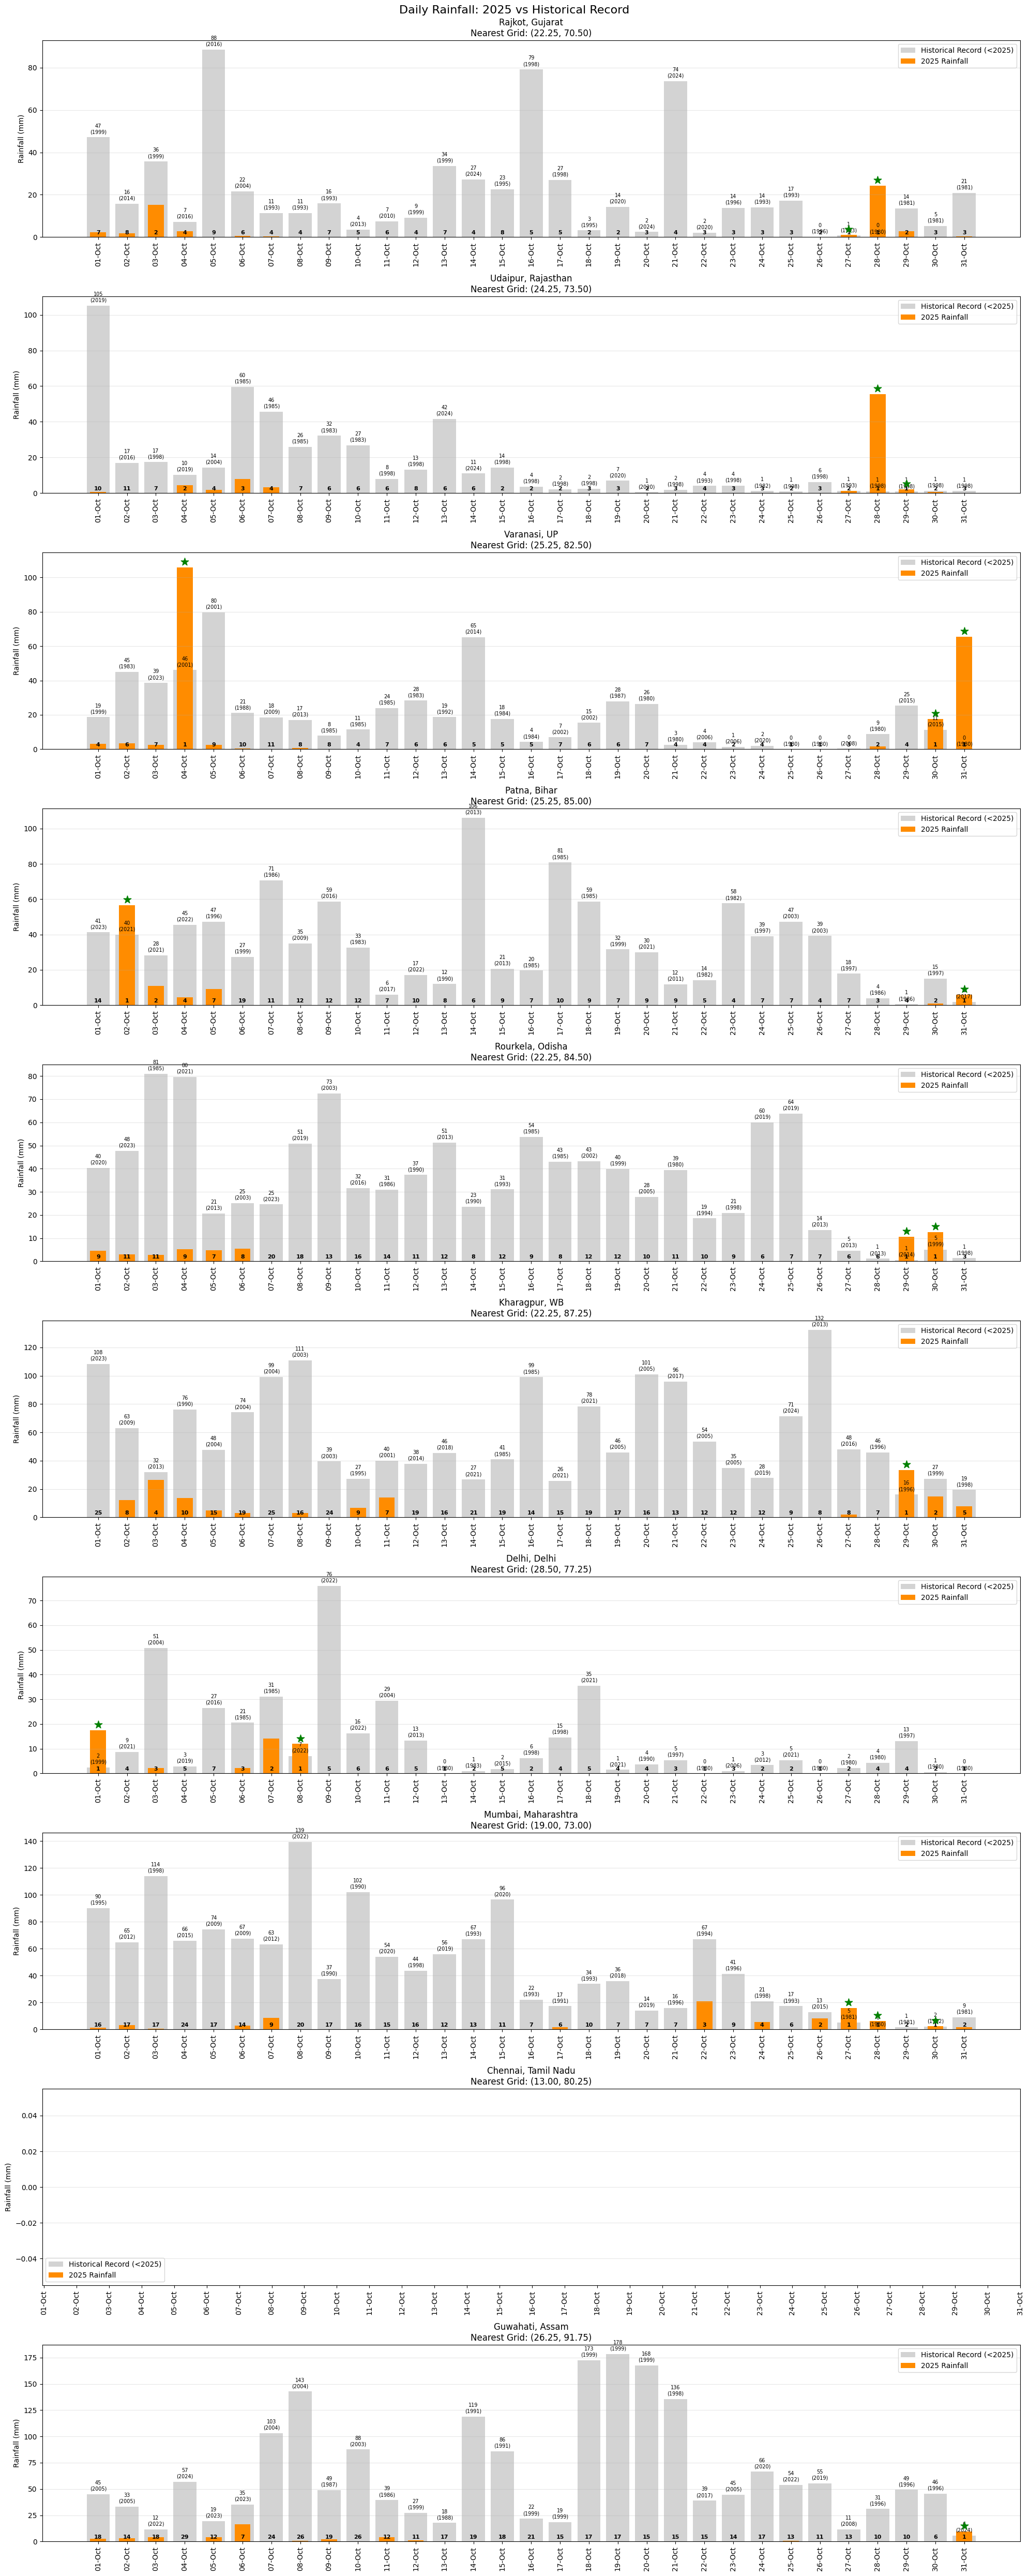

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# USER INPUT
# =====================================================

merged_file = r"D:\PHD IIT KGP\2. IMD GRIED (0.25X0.25) RAINFALL\IMD_Rainfall_Merged.nc"

start_date = "2025-10-01"
end_date   = "2025-10-31"

locations = [
    ("Rajkot, Gujarat",   22.18, 70.48),
    ("Udaipur, Rajasthan",  24.34, 73.42),
    ("Varanasi, UP", 25.18, 82.57),
    ("Patna, Bihar",   25.34, 85.08),
    ("Rourkela, Odisha", 22.15, 84.51),
    ("Kharagpur, WB", 22.35, 87.32),
    ("Delhi, Delhi",     28.61, 77.21),
    ("Mumbai, Maharashtra",    19.07, 72.88),
    ("Chennai, Tamil Nadu",   13.08, 80.27),
    ("Guwahati, Assam",  26.14, 91.74),
]

# =====================================================
# LOAD DATA
# =====================================================

ds = xr.open_dataset(merged_file)

rain_var = list(ds.data_vars)[0]

target_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="D"
)

# =====================================================
# FIGURE
# =====================================================

nloc = len(locations)

fig, axes = plt.subplots(
    nloc,
    1,
    figsize=(20, 5*nloc),
    sharex=False
)

if nloc == 1:
    axes = [axes]

# =====================================================
# LOOP OVER LOCATIONS
# =====================================================

for ax, (name, lat, lon) in zip(axes, locations):

    rain = ds[rain_var].sel(
        LATITUDE=lat,
        LONGITUDE=lon,
        method="nearest"
    )

    actual_lat = float(rain.LATITUDE.values)
    actual_lon = float(rain.LONGITUDE.values)

    record_vals = []
    record_years = []

    rain_2025_vals = []

    ranks_2025 = []

    broke_record = []

    # =================================================
    # LOOP THROUGH DAYS
    # =================================================

    for date in target_dates:

        month = date.month
        day = date.day

        same_day = rain.sel(
            TIME=(
                (rain.TIME.dt.month == month)
                &
                (rain.TIME.dt.day == day)
            )
        )

        df = same_day.to_dataframe(
            name="rain"
        ).reset_index()

        df["year"] = df["TIME"].dt.year

        # ---------------------------------------------
        # 2025 VALUE
        # ---------------------------------------------

        tmp2025 = df.loc[
            df["year"] == 2025,
            "rain"
        ]

        if len(tmp2025) == 0 or pd.isna(tmp2025.iloc[0]):

            val_2025 = np.nan
            rank = np.nan

        else:

            val_2025 = float(tmp2025.iloc[0])

            valid_vals = (
                df["rain"]
                .dropna()
                .values
            )

            rank = (
                np.sum(valid_vals > val_2025)
                + 1
            )

        # ---------------------------------------------
        # HISTORICAL RECORD (<2025)
        # ---------------------------------------------

        hist = df[
            df["year"] < 2025
        ].copy()

        hist = hist.dropna(
            subset=["rain"]
        )

        if len(hist) == 0:

            record_val = np.nan
            record_year = np.nan

            is_record = False

        else:

            idx = hist["rain"].idxmax()

            record_val = float(
                hist.loc[idx, "rain"]
            )

            record_year = int(
                hist.loc[idx, "year"]
            )

            if np.isnan(val_2025):

                is_record = False

            else:

                is_record = (
                    val_2025 > record_val
                )

        record_vals.append(record_val)
        record_years.append(record_year)

        rain_2025_vals.append(val_2025)

        ranks_2025.append(rank)

        broke_record.append(is_record)

    # =================================================
    # PLOT
    # =================================================

    x = np.arange(len(target_dates))

    # Historical record

    ax.bar(
        x,
        record_vals,
        width=0.80,
        color="lightgray",
        label="Historical Record (<2025)"
    )

    # 2025

    ax.bar(
        x,
        rain_2025_vals,
        width=0.55,
        color="darkorange",
        label="2025 Rainfall"
    )

    ymax = np.nanmax(
        np.concatenate([
            np.array(record_vals),
            np.array(rain_2025_vals)
        ])
    )

    # =================================================
    # RECORD LABELS
    # =================================================

    for i in range(len(x)):

        if np.isnan(record_vals[i]):
            continue

        ax.text(
            x[i],
            record_vals[i] + ymax*0.02,
            f"{record_vals[i]:.0f}\n({record_years[i]})",
            fontsize=7,
            ha="center"
        )

    # =================================================
    # RANK LABELS
    # =================================================

    for i in range(len(x)):

        if np.isnan(ranks_2025[i]):
            continue

        ax.text(
            x[i],
            ymax*0.01,
            f"{int(ranks_2025[i])}",
            fontsize=8,
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    # =================================================
    # RECORD BREAKER MARKER
    # =================================================

    for i in range(len(x)):

        if broke_record[i]:

            ax.scatter(
                x[i],
                rain_2025_vals[i] + ymax*0.03,
                marker="*",
                s=120,
                color="green",
                zorder=10
            )

    # =================================================
    # AXIS SETTINGS
    # =================================================

    labels = [
        d.strftime("%d-%b")
        for d in target_dates
    ]

    ax.set_xticks(x)

    ax.set_xticklabels(
        labels,
        rotation=90
    )

    ax.set_ylabel(
        "Rainfall (mm)"
    )

    ax.set_title(
        f"{name}\n"
        f"Nearest Grid: "
        f"({actual_lat:.2f}, {actual_lon:.2f})"
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )

    ax.legend()

# =====================================================
# FIGURE TITLE
# =====================================================

fig.suptitle(
    "Daily Rainfall: 2025 vs Historical Record",
    fontsize=16,
    y=0.995
)

plt.tight_layout()

plt.show()